# 07 - Offline 3DVar reconstruction (same-model PPE)

3DVar in the gain (dual) form, assimilating in anomaly space. The analysis is

    x_a = x_b + B H^T (H B H^T + R)^-1 (y - H x_b)

with H nearest-cell selection and R = diag(sse). The only inverse is the m x m matrix
over one age's observations. The background covariance is a single pixel model whose
regularization is tuned: three composable, diagonal-preserving tapers (Gaspari-Cohn
localization L, diagonal shrinkage lambda, and a cross-channel coupling factor alpha)
are jointly selected with the B-vs-R amplitude b_scale on the held-out selection split.
B is built from the older chronological half of the LOVECLIM prior under a single
climatological background.

The same-model PPE truths are the younger half of the LOVECLIM run: the age axis is
split at its midpoint, B and the climatology come from the older half, and truths are
drawn from the younger half (subsampled to near-independent states) and anomalised by
their own climatology, so the prior reconstructs a held-out chronological chunk of its
own model. Each truth borrows several real proxy network shapes; pseudo-observations
are the truth at each nearest cell plus N(0, sse) noise. The operating point is selected
on held-out shapes and scored on a disjoint one; every metric row carries a
selection/test split.

This notebook runs the pixel regularizer grid, selects one operating point per lane, and
renders the tuning landscape. The reconstruction diagnostics, cross-method comparison and
field gallery live in 09_da_comparison. Heavy compute lives in paleoreco.assim.experiments.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads. The assimilation runs thousands of small
# (~130x130) eigendecompositions per config, a size where splitting each one across
# cores costs far more in thread setup than it saves; left uncapped it also saturates a
# shared machine. These variables are read only when numpy first initialises, so they
# have to be set above the numpy import.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/07_3dvar")
FIG.mkdir(parents=True, exist_ok=True)

# The cap fails silently if numpy was already imported, so time the operation it
# protects: ~2 ms per call means capped, tens of ms means it did not take effect.
_a = np.random.default_rng(0).normal(size=(130, 130))
_a = _a @ _a.T
_t0 = time.perf_counter()
for _ in range(5):
    np.linalg.eigh(_a)
print(f"eigh(130x130): {1e3 * (time.perf_counter() - _t0) / 5:.1f} ms/call "
      f"(~2 ms expected with threads capped)")

eigh(130x130): 1.2 ms/call (~2 ms expected with threads capped)


## Prior cube, chronological split, and observation network

B and the climatology use the older chronological half of the LOVECLIM prior; the
younger half supplies the same-model PPE truths (age axis split at its midpoint,
younger states subsampled to near-independent truths, each anomalised by its own
climatology). The withholding lane assimilates real proxies in anomaly space (y minus
per-site climatology), so it needs the site statistics, estimated on the collapsed
(one-row-per-sample) table.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")

cube (804, 2, 32, 64), 804 ages, 187 sites


## Tune the pixel regularizer

The localization/shrinkage/alpha grid is scored on the same-model PPE and the real-proxy
k-fold withholding lane; each lane jointly selects its operating point (localization,
shrinkage, alpha, b_scale) on the held-out selection split (pooled RRMSE, prefer-simpler
within tolerance). The full grid of metrics is written to one directory, the winning
config's analysis fields and predictions alongside. Re-running clears the directory first
so the appended metrics CSV stays clean.

The withholding lane assimilates each proxy with `R = diag(sse + rep_var)`, adding the per-site representativeness variance so a point proxy is not trusted to resolve its 5.625 degree cell; the same term enters the predictive variance that scores the withheld sites. The PPE lane keeps `R = diag(sse)`.

In [3]:
# GRID = dict(localization_grid=ex.LOCALIZATION_KM_GRID,
#             shrinkage_grid=ex.SHRINKAGE_GRID, alpha_grid=ex.ALPHA_GRID)
GRID = dict(
    localization_grid=(None, 5000.0, 7500.0, 10000.0, 12500.0, 15000.0, 20000.0),
    shrinkage_grid=(0.0, 0.25, 0.5, 0.75),
    alpha_grid=(0.0, 0.25, 0.5, 0.75, 1.0),
)
N_NOISE = 5                                           # pseudo-obs noise draws averaged per shape

d = OUT / "3dvar_pixel"
if d.exists():
    shutil.rmtree(d)
print("[pixel] ppe grid")
ex.run_ppe_pixel_grid(cube, ages, lats, lons, valid, long_ppe, str(d),
                      n_noise=N_NOISE, truth_stride=10, progress_every=5, **GRID)
print("[pixel] withholding random grid")
ex.run_withholding_pixel_grid(cube, ages, lats, lons, valid, long_wh, str(d),
                              fold_kind="random", progress_every=1, **GRID)
print("done")

[pixel] ppe grid
  pixel-grid config 1/140 (1%, elapsed 8s, eta 1148s)
  pixel-grid config 2/140 (1%, elapsed 16s, eta 1128s)
  pixel-grid config 3/140 (2%, elapsed 24s, eta 1109s)
  pixel-grid config 4/140 (3%, elapsed 32s, eta 1097s)
  pixel-grid config 5/140 (4%, elapsed 41s, eta 1103s)
  pixel-grid config 6/140 (4%, elapsed 50s, eta 1118s)
  pixel-grid config 7/140 (5%, elapsed 59s, eta 1123s)
  pixel-grid config 8/140 (6%, elapsed 70s, eta 1160s)
  pixel-grid config 9/140 (6%, elapsed 81s, eta 1182s)
  pixel-grid config 10/140 (7%, elapsed 90s, eta 1173s)
  pixel-grid config 11/140 (8%, elapsed 100s, eta 1168s)
  pixel-grid config 12/140 (9%, elapsed 110s, eta 1177s)
  pixel-grid config 13/140 (9%, elapsed 121s, eta 1186s)
  pixel-grid config 14/140 (10%, elapsed 133s, eta 1195s)
  pixel-grid config 15/140 (11%, elapsed 142s, eta 1186s)
  pixel-grid config 16/140 (11%, elapsed 154s, eta 1195s)
  pixel-grid config 17/140 (12%, elapsed 163s, eta 1179s)
  pixel-grid config 18/140 (13

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float

  pixel-grid config (withholding_random) 121/140 (86%, elapsed 7310s, eta 1148s)


/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float

  pixel-grid config (withholding_random) 122/140 (87%, elapsed 7355s, eta 1085s)


...

  pixel-grid config (withholding_random) 124/140 (89%, elapsed 7480s, eta 965s)


/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float

  pixel-grid config (withholding_random) 125/140 (89%, elapsed 7549s, eta 906s)


/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:43: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))
/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleoreco/eval/calibration.py:29: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(np.asarray(var, dtype=np.float64))


  pixel-grid config (withholding_random) 126/140 (90%, elapsed 7616s, eta 846s)
  pixel-grid config (withholding_random) 127/140 (91%, elapsed 7677s, eta 786s)
  pixel-grid config (withholding_random) 128/140 (91%, elapsed 7740s, eta 726s)
  pixel-grid config (withholding_random) 129/140 (92%, elapsed 7806s, eta 666s)
  pixel-grid config (withholding_random) 130/140 (93%, elapsed 7869s, eta 605s)
  pixel-grid config (withholding_random) 131/140 (94%, elapsed 7921s, eta 544s)
  pixel-grid config (withholding_random) 132/140 (94%, elapsed 7988s, eta 484s)
  pixel-grid config (withholding_random) 133/140 (95%, elapsed 8036s, eta 423s)
  pixel-grid config (withholding_random) 134/140 (96%, elapsed 8081s, eta 362s)
  pixel-grid config (withholding_random) 135/140 (96%, elapsed 8148s, eta 302s)
  pixel-grid config (withholding_random) 136/140 (97%, elapsed 8216s, eta 242s)
  pixel-grid config (withholding_random) 137/140 (98%, elapsed 8281s, eta 181s)
  pixel-grid config (withholding_random)

## Regularization tuning landscape

The pixel covariance is one tuned config, not four hand-picked variants. This is the
PPE selection-split RRMSE over the (localization, shrinkage, alpha) grid, reduced over
b_scale (the best b_scale per taper config), with the selected config starred. A flat
landscape means the operating point is weakly determined, so the prefer-simpler rule
keeps it near raw. The per-lane selected configs are tabulated below.

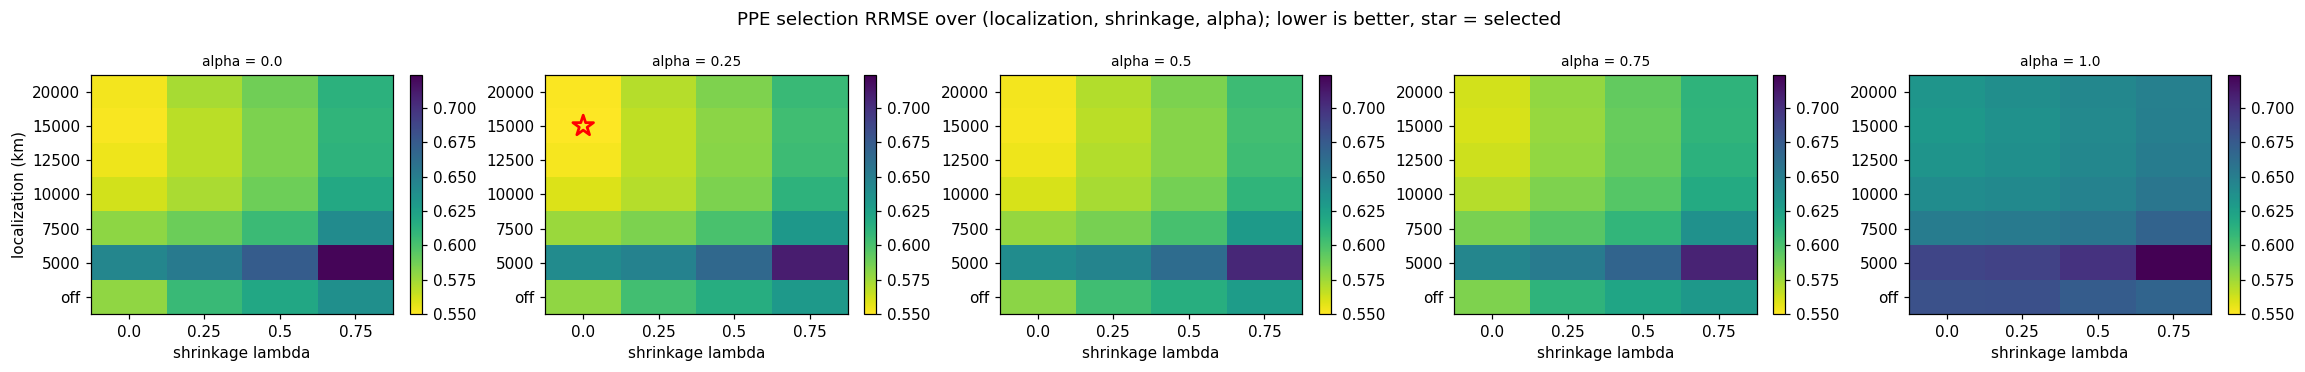

Selected pixel config per lane:


,localization_km,shrinkage_lambda,alpha,b_scale
ppe,15000.0,0.0,0.25,2.0
withholding_random,NaN,0.5,0.50,1.0


In [4]:
M = pd.read_csv(OUT / "3dvar_pixel" / "metrics.csv")
sel_df = M[(M.lane == "ppe") & (M.method == "3dvar") & (M.channel == "pooled")
           & (M.do_event == "all") & (M.split == "selection") & (M.metric == "rrmse")].copy()
sel_df["loc_km"] = sel_df["localization_km"].fillna(-1.0)   # -1 = localization off
prof = sel_df.groupby(["loc_km", "shrinkage_lambda", "alpha"])["value"].min().reset_index()

locs = sorted(prof["loc_km"].unique())
lams = sorted(prof["shrinkage_lambda"].unique())
alphas = sorted(prof["alpha"].unique())
loc_lab = ["off" if lk < 0 else f"{int(lk)}" for lk in locs]

win = json.load(open(OUT / "3dvar_pixel" / "ppe_config.json"))["selected"]
win_loc = -1.0 if win["localization_km"] is None else float(win["localization_km"])

vmin, vmax = float(prof["value"].min()), float(prof["value"].max())
fig, axes = plt.subplots(1, len(alphas), figsize=(4.2 * len(alphas), 3.4), squeeze=False)
for ai, a in enumerate(alphas):
    ax = axes[0, ai]
    grid = np.full((len(locs), len(lams)), np.nan)
    for li, lk in enumerate(locs):
        for mi, m in enumerate(lams):
            v = prof[(prof["loc_km"] == lk) & (prof["shrinkage_lambda"] == m)
                     & (prof["alpha"] == a)]["value"]
            if len(v):
                grid[li, mi] = v.iloc[0]
    im = ax.imshow(grid, origin="lower", cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(lams))); ax.set_xticklabels(lams)
    ax.set_yticks(range(len(locs))); ax.set_yticklabels(loc_lab)
    ax.set_xlabel("shrinkage lambda")
    if ai == 0:
        ax.set_ylabel("localization (km)")
    ax.set_title(f"alpha = {a}", fontsize=9)
    if abs(a - win["alpha"]) < 1e-9 and win_loc in locs and win["shrinkage_lambda"] in lams:
        ax.scatter([lams.index(win["shrinkage_lambda"])], [locs.index(win_loc)],
                   s=200, marker="*", facecolors="none", edgecolors="red", linewidths=1.8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("PPE selection RRMSE over (localization, shrinkage, alpha); lower is better, star = selected")
fig.tight_layout()
fig.savefig(str(FIG / "tuning_landscape_ppe.png"), dpi=110, bbox_inches="tight")
plt.show()

# Selected config per lane.
lanes = [("ppe", "ppe_config.json"),
         ("withholding_random", "withholding_random_config.json")]
winners = {lane: json.load(open(OUT / "3dvar_pixel" / fn))["selected"] for lane, fn in lanes}
print("Selected pixel config per lane:")
display(pd.DataFrame(winners).T)

## Reading

- The tuning landscape shows how much the selection metric moves across the taper grid;
  a flat landscape means the operating point is weakly determined, so the prefer-simpler
  rule keeps the config close to raw.
- alpha is the cross-channel knob: alpha -> 0 decouples mtco and mtwa, isolating whether
  LOVECLIM's cross-channel covariance helps or hurts the weaker mtwa channel.
- alpha is also the knob the pooled selection metric is least able to judge: mtco carries
  most of the pooled variance, so a config good for mtco can be selected while mtwa is
  scored worse than doing nothing. Read the per-channel rows, not just pooled.
- Each lane selects its own operating point, so the winning taper config differs between
  the PPE and withholding lanes; neither is a global optimum.
- This notebook writes the calibration inputs (posterior variance, per-site proxy error,
  distance to the nearest assimilated site) alongside the skill metrics.
- Skill maps, the cross-method comparison (pixel vs latent vs naive), the calibration
  block, and the field gallery are in 09_da_comparison. Withholding CE is small by
  construction; it is only interpretable next to the prior-free baselines and the
  calibration scores reported there.